# 06 · Conclusiones
**Proyecto:** Predicción de abandono de clientes – Telco Customer Churn

---
## Objetivo de este notebook
Sintetizar los resultados obtenidos, responder la pregunta guía del proyecto
y presentar recomendaciones, limitaciones y mejoras futuras.

**Importaciones**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

**Carga de datos y modelos**

In [3]:
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
X_test        = pd.read_csv('../data/processed/X_test.csv')
y_test        = pd.read_csv('../data/processed/y_test.csv').squeeze()

lr_best  = joblib.load('../models/logistic_regression.joblib')
dt_best  = joblib.load('../models/decision_tree.joblib')

models = [
    ('Regresión Logística', lr_best.predict(X_test_scaled),  lr_best.predict_proba(X_test_scaled)[:, 1]),
    ('Árbol de Decisión',   dt_best.predict(X_test),         dt_best.predict_proba(X_test)[:, 1]),
]

**Tabla comparativa final**

In [4]:
rows = []
for name, y_pred, y_prob in models:
    rows.append({
        'Modelo':            name,
        'Accuracy':          round(accuracy_score(y_test, y_pred), 4),
        'Precision (Churn)': round(precision_score(y_test, y_pred), 4),
        'Recall (Churn)':    round(recall_score(y_test, y_pred), 4),
        'F1 (Churn)':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':           round(roc_auc_score(y_test, y_prob), 4),
    })

summary_df = pd.DataFrame(rows).set_index('Modelo')
summary_df

,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Modelo,,,,,
Regresión Logística,0.8020,0.6508,0.5481,0.5951,0.8432
Árbol de Decisión,0.7864,0.6478,0.4278,0.5153,0.8303


**Visualización de métricas clave**

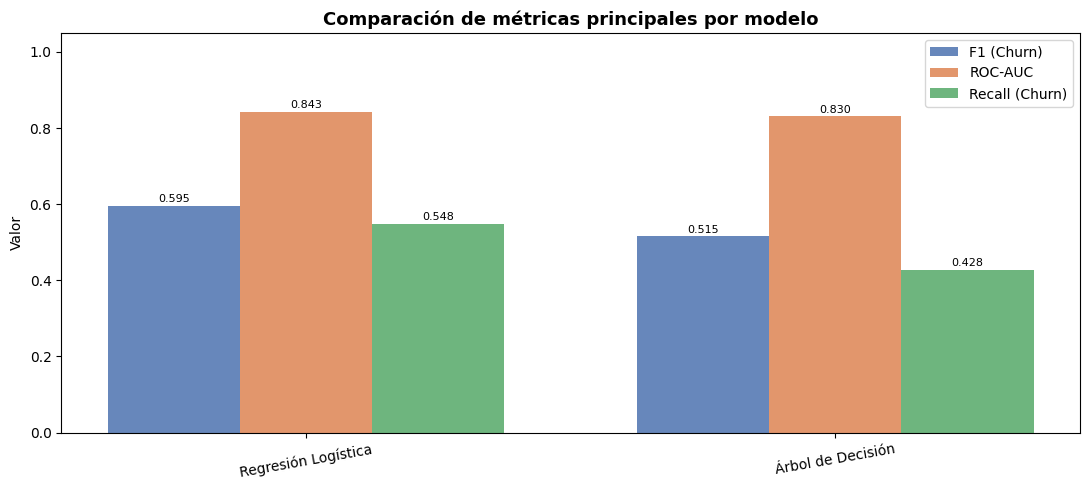

In [ ]:
metrics = ['F1 (Churn)', 'ROC-AUC', 'Recall (Churn)']
x = np.arange(len(summary_df))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, summary_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(summary_df.index, rotation=10)
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de métricas principales por modelo', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Respuesta a la pregunta guía**

> *¿Qué características están más asociadas al abandono de clientes y qué modelo permite justificar mejor la decisión?*

Todos los modelos destacan las mismas variables como las más relevantes:

* **Tipo de contrato (`Contract`):** es el predictor más fuerte. Clientes con contrato mensual abandonan a una tasa significativamente mayor que los de contrato anual o bianual. Un contrato largo genera un compromiso que reduce la probabilidad de churn.
* **Antigüedad (`tenure`):** a mayor tiempo como cliente, menor probabilidad de abandono. Los clientes nuevos son los más vulnerables.
* **Servicio de internet (`InternetService_Fiber optic`):** clientes con fibra óptica presentan mayor tasa de churn, posiblemente por mayor costo mensual o mayor competencia en ese segmento.
* **Cargos mensuales (`MonthlyCharges`):** cargos altos correlacionan con mayor abandono.
* **Soporte técnico y seguridad online:** la ausencia de estos servicios aumenta el riesgo de churn.

> *¿Qué modelo justifica mejor la decisión?*

**En términos de rendimiento:** Regresión Logística y Árbol de Decisión obtienen resultados comparables en ROC-AUC y F1 en este conjunto. El árbol tiende a sobreajustar sin restricciones y la regresión logística se beneficia del escalado y regularización.

**En términos de justificación:** El árbol produce reglas accionables del tipo *"si el cliente tiene contrato mensual y lleva menos de 12 meses → riesgo alto"*, que son fáciles de comunicar a equipos no técnicos.

**Recomendación práctica:** usar Regresión Logística para scoring cuando se requieran probabilidades bien calibradas y el Árbol de Decisión para explicar decisiones al negocio.

**Interpretación**

El modelo no busca solo predecir con certeza si un cliente se irá, sino también ordenar a los clientes por nivel de riesgo para que el equipo comercial priorice sus acciones de retención.

Un ROC-AUC de aproximadamente 0.85 representa que en 85 de cada 100 comparaciones entre un cliente que abandona y uno que no, el modelo asigna mayor probabilidad de churn al que realmente se va.

En la práctica esto se traduce en:
* Identificar los clientes de mayor riesgo antes de que abandonen
* Priorizar campañas de retención en ese segmento
* Reducir el costo de adquisición de nuevos clientes al retener los existentes

El error más costoso es el falso negativo, donde un cliente va a abandonar y el modelo no lo detecta.

**Efecto del ajuste de hiperparámetros**

| Modelo | Hiperparámetro | Efecto observado |
|--------|---------------|------------------|
| Regresión Logística | `C` | Valores extremos (muy alto o muy bajo) reducen ROC-AUC. El valor óptimo balancea sesgo y varianza. |
| Árbol de Decisión | `max_depth` | Sin restricción el árbol hace overfitting severo. Limitar la profundidad mejora la generalización. |
| Árbol de Decisión | `criterion` | `gini` y `entropy` producen resultados similares en este dataset. |

**Efecto del preprocesamiento**

- Eliminar `customerID` evitó que el modelo aprendiera un patrón espurio sobre un identificador.
- Imputar `TotalCharges` con 0 preservó 11 registros válidos de clientes nuevos sin cargos acumulados.
- One-Hot Encoding con `drop_first=True` permitió representar variables categóricas sin introducir multicolinealidad perfecta.
- StandardScaler mejoró la convergencia de la Regresión Logística. El Árbol de Decisión demostró ser invariante al escalado.
- El split estratificado 60/20/20 garantizó que la proporción de churn (~26.5%) se mantuviera en los tres conjuntos.

**Limitaciones del dataset y los modelos**

* **Dataset desbalanceado:** el modelo tiene más dificultad para detectar correctamente la clase minoritaria. Se decidió no balancear artificialmente para mantener la distribución real del negocio.
* **Falta variables importantes:** el dataset no incluye información sobre interacciones con servicio al cliente, historial de quejas o comparación con la competencia, los cuales podrían ser factores relevantes para la predicción.
* **Multicolinealidad:** `MonthlyCharges` y `TotalCharges` presentan una alta correlación, lo que puede afectar la interpretación de los coeficientes de la Regresión Logística.

**Mejoras futuras**

* **`class_weight='balanced'`** en Regresión Logística y Árbol de Decisión para penalizar más los Falsos Negativos sin modificar los datos.
* **Features adicionales:** incorporar variables de interacción como `MonthlyCharges × tenure` o indicadores derivados del comportamiento de uso.
* **Validación temporal:** dividir los datos por fecha de registro para simular un escenario de predicción real.